In [22]:
# Import libraries
import subprocess
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

# Enable inline plotting
%matplotlib inline

# Set consistent plot style (matching namespace_resources.ipynb)
sns.set_theme(style='whitegrid', font_scale=1.7)

print("Libraries loaded ✓")

Libraries loaded ✓


## Configuration

Configure the Kubernetes namespaces and pod selectors for each RIC component.

In [23]:
# Kubernetes Configuration
KUBECONFIG = None  # Set path if not using default ~/.kube/config

# Namespace configuration for O-RAN components (including SMO and Non-RT RIC)
NAMESPACES = {
    "frontend": "Frontend (User Interface - Intent Submission)",
    "smo": "SMO (MCP Client/Server - Intent Management)",
    "ricrapp": "rApp (rApps - Intent to Policy Translation)",
    "nonrtric": "Non-RT RIC (Policy Management, Gateway)",
    "ricplt": "Near-RT RIC Platform (A1 Mediator, E2Term, E2Mgr)",
    "ricxapp": "Near-RT RIC xApps (orion-xapp, e2sim)",
}

# Pod label selectors for each component
POD_SELECTORS = {
    # Frontend Layer (User Interface)
    "frontend": {"namespace": "frontend", "label": "app.kubernetes.io/name=frontend"},
    # SMO Layer
    "mcp-client": {"namespace": "smo", "label": "app.kubernetes.io/name=mcp-client"},
    "mcp-server": {"namespace": "smo", "label": "app.kubernetes.io/name=mcp-server"},
    # rApp Layer (Intent to A1 Policy translation)
    "rapp": {"namespace": "ricrapp", "label": "app.kubernetes.io/name=rapp"},
    # Non-RT RIC Layer
    "policymanagement": {"namespace": "nonrtric", "label": "app=nonrtric-policymanagementservice"},
    "a1controller": {"namespace": "nonrtric", "label": "app=nonrtric-a1controller"},
    # Near-RT RIC Platform
    "a1mediator": {"namespace": "ricplt", "label": "app=ricplt-a1mediator"},
    "e2term": {"namespace": "ricplt", "label": "app=ricplt-e2term-alpha"},
    "e2mgr": {"namespace": "ricplt", "label": "app=ricplt-e2mgr"},
    # Near-RT RIC xApps
    "orion-xapp": {"namespace": "ricxapp", "label": "app=ricxapp-orion-xapp"},
    # E2 Node Simulator - NOTE: runs in ricxapp namespace
    "e2sim": {"namespace": "ricxapp", "label": "app.kubernetes.io/name=e2sim-helm"},
}

# Time window for log analysis - capture recent activity including rApp
LOG_SINCE_MINUTES = 120  # Increased to capture rApp logs from last intent (1.5h ago)

# Increase to capture logs from earlier SMO activity
LOG_SINCE_HOURS = 24  # For SMO components that may have older logs

print("Configuration loaded ✓")
print(f"\nAnalyzing logs from the last {LOG_SINCE_MINUTES} minutes (or {LOG_SINCE_HOURS}h for SMO)")

print(f"\nComponents to analyze:")
for component, selector in POD_SELECTORS.items():
    print(f"  - {component}: {selector['namespace']}/{selector['label']}")

Configuration loaded ✓

Analyzing logs from the last 120 minutes (or 24h for SMO)

Components to analyze:
  - frontend: frontend/app.kubernetes.io/name=frontend
  - mcp-client: smo/app.kubernetes.io/name=mcp-client
  - mcp-server: smo/app.kubernetes.io/name=mcp-server
  - rapp: ricrapp/app.kubernetes.io/name=rapp
  - policymanagement: nonrtric/app=nonrtric-policymanagementservice
  - a1controller: nonrtric/app=nonrtric-a1controller
  - a1mediator: ricplt/app=ricplt-a1mediator
  - e2term: ricplt/app=ricplt-e2term-alpha
  - e2mgr: ricplt/app=ricplt-e2mgr
  - orion-xapp: ricxapp/app=ricxapp-orion-xapp
  - e2sim: ricxapp/app.kubernetes.io/name=e2sim-helm


## Kubernetes Log Fetching Functions

Functions to retrieve logs from pods using `kubectl`.

In [24]:
def run_kubectl(args: list) -> str:
    """Run a kubectl command and return output."""
    cmd = ["kubectl"]
    if KUBECONFIG:
        cmd.extend(["--kubeconfig", KUBECONFIG])
    cmd.extend(args)
    
    try:
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=120)
        if result.returncode != 0:
            print(f"kubectl error: {result.stderr[:200]}")
            return ""
        return result.stdout
    except subprocess.TimeoutExpired:
        print(f"kubectl command timed out: {' '.join(cmd)}")
        return ""
    except Exception as e:
        print(f"Error running kubectl: {e}")
        return ""


def get_pods(namespace: str, label_selector: str = None) -> list:
    """Get list of pod names in a namespace."""
    args = ["get", "pods", "-n", namespace, "-o", "jsonpath={.items[*].metadata.name}"]
    if label_selector:
        args.extend(["-l", label_selector])
    
    output = run_kubectl(args)
    if output:
        return output.split()
    return []


def get_pod_logs(namespace: str, pod_name: str, since_minutes: int = 60, container: str = None) -> str:
    """Fetch logs from a specific pod."""
    args = ["logs", "-n", namespace, pod_name, f"--since={since_minutes}m", "--timestamps=true"]
    if container:
        args.extend(["-c", container])
    
    return run_kubectl(args)


def fetch_component_logs(component: str, use_extended_time: bool = False) -> dict:
    """Fetch logs for all pods of a component.
    
    Args:
        component: Name of the component
        use_extended_time: If True, use LOG_SINCE_HOURS instead of LOG_SINCE_MINUTES
    """
    if component not in POD_SELECTORS:
        print(f"Unknown component: {component}")
        return {}
    
    selector = POD_SELECTORS[component]
    namespace = selector["namespace"]
    label = selector.get("label")
    
    # Use extended time for SMO, rApp, and Frontend components (they only log during intent flows)
    if use_extended_time or namespace in ["smo", "ricrapp", "frontend"]:
        since_minutes = LOG_SINCE_HOURS * 60
    else:
        since_minutes = LOG_SINCE_MINUTES
    
    pods = get_pods(namespace, label)
    if not pods:
        # Try without label selector
        pods = get_pods(namespace)
        # Filter by component name
        comp_clean = component.replace("-", "").lower()
        pods = [p for p in pods if comp_clean in p.replace("-", "").lower()]
    
    logs = {}
    for pod in pods:
        log_content = get_pod_logs(namespace, pod, since_minutes)
        if log_content:
            logs[pod] = log_content
            print(f"  ✓ {pod}: {len(log_content.splitlines())} lines")
        else:
            print(f"  ✗ {pod}: No logs or error")
    
    return logs


print("Kubernetes functions defined ✓")

Kubernetes functions defined ✓


## Log Parsing Functions

Parse timestamps and message patterns from different component logs.

In [25]:
# Regex patterns for different log formats
TIMESTAMP_PATTERNS = [
    # ISO 8601 format (kubectl --timestamps=true)
    r"^(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d+)",
    # mdclog JSON format with "ts" field (milliseconds)
    r'"ts":(\d{13})',
    # Python logging format (YYYY-MM-DD HH:MM:SS,mmm)
    r"(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2},\d{3})",
    # Go log format
    r"(\d{4}/\d{2}/\d{2} \d{2}:\d{2}:\d{2})",
    # e2sim custom logger format (HH:MM:SS.mmm)
    r"(\d{2}:\d{2}:\d{2}\.\d{3})",
]

# Message patterns for each component - Including SMO and Non-RT RIC
# NOTE: Patterns verified against actual source code (2026-01-14)
MESSAGE_PATTERNS = {
    # Frontend Layer - User Interface
    "frontend": {
        "connecting": r"Connecting to",
        "intent_submitted": r"Submitting intent",
        "response_received": r"Received response",
    },
    # SMO Layer - MCP Client (Intent Management)
    "mcp-client": {
        "intent_received": r"Processing intent payload",
        "llm_call": r"Calling LLM",
        "tool_executed": r"Executing tool",
        "tool_result": r"Tool result",
        "policy_type_set": r"Setting policy type",
        "policy_created": r"(?:Creating policy instance|Policy instance created)",
        "mcp_connected": r"Successfully connected to server",
    },
    # SMO Layer - MCP Server (Interpretation Scheme)
    "mcp-server": {
        "session_created": r"create_session",
        "request_received": r"POST /messages",
        "sse_connected": r"GET /sse",
    },
    # rApp Layer - Intent to A1 Policy Translation
    "rapp": {
        "policy_request_received": r"Policy request received",
        "sending_put_request": r"Sending PUT request",
        "policy_created_successfully": r"Policy created successfully",
        "http_post": r"POST /create_policy",
    },
    # Non-RT RIC - Policy Management Service
    "policymanagement": {
        "policy_created": r"(?:Created|created).*policy",
        "policy_updated": r"(?:Updated|updated).*policy",
        "policy_put": r"(?:PUT|put).*policy",
        "a1_client": r"A1Client",
        "ric_communication": r"Near-RT RIC",
    },
    # Non-RT RIC - A1 Controller
    "a1controller": {
        "a1_request": r"(?:A1.*request|Request.*A1)",
        "a1_response": r"(?:A1.*response|Response.*A1)",
    },
    # Near-RT RIC - A1 Mediator
    "a1mediator": {
        "policy_received": r"(?:Received|received|POST|policy.*request)",
        "policy_forwarded": r"(?:Forward|forward|rmr.*send|delivered)",
    },
    # Near-RT RIC - E2 Term
    "e2term": {
        "msg_received": r"(?:Received|received|incoming)",
        "msg_sent": r"(?:Sent|sent|outgoing)",
        "control_request": r"(?:RIC.*CONTROL.*REQ|12040)",
        "control_ack": r"(?:RIC.*CONTROL.*ACK|12041)",
    },
    # Near-RT RIC - E2 Manager
    "e2mgr": {
        "e2_setup": r"(?:E2.*Setup|setup.*E2)",
        "ran_connected": r"(?:RAN.*connected|Connected.*RAN)",
    },
    # Near-RT RIC - Orion xApp (patterns verified against main.cpp)
    "orion-xapp": {
        "a1_policy_received": r"Received A1 Policy",  # INFO level - main.cpp:83
        "policy_handler_called": r"A1 Handler has been called",  # DEBUG level - main.cpp:80
        # Fixed: actual log message is "Sending Control Request for Slice SLA Policy" (main.cpp:138)
        "control_sent": r"Sending Control Request for Slice SLA Policy",
        "control_ack": r"RIC_CONTROL_ACK",  # INFO level - main.cpp:146
        "control_failure": r"RIC_CONTROL_FAILURE",  # WARN level - main.cpp:161
        "a1_response": r"A1 Response is",  # DEBUG level - main.cpp:171
        "e2_node_discovered": r"Discovered capacity for E2 Node",  # INFO level - e2mgr.cpp
    },
    # E2 Node Simulator (patterns verified against rc_callbacks.cpp)
    "e2sim": {
        "control_received": r"\[E2AP\].*Received RIC-CONTROL-REQUEST",  # e2ap_message_handler.cpp
        "control_header": r"Received E2SM-RC Control Header",  # rc_callbacks.cpp
        "slice_extracted": r"extracted Slice SLA Policy",  # rc_callbacks.cpp
        "slice_registered": r"Slice registered",  # rc_callbacks.cpp
        "control_ack_sent": r"Sending RIC-CONTROL-ACKNOWLEDGE",  # rc_callbacks.cpp
    },
}


def parse_timestamp_from_kubectl(line: str) -> datetime:
    """Extract timestamp from kubectl --timestamps output (ISO 8601 at start of line)."""
    match = re.match(r"^(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d+)", line)
    if match:
        ts_str = match.group(1)[:26]  # Trim to microseconds
        try:
            return datetime.fromisoformat(ts_str)
        except ValueError:
            pass
    return None


def parse_timestamp_from_json(line: str) -> datetime:
    """Extract timestamp from JSON log format with 'ts' field (milliseconds)."""
    match = re.search(r'"ts":(\d{13})', line)
    if match:
        ts_ms = int(match.group(1))
        return datetime.fromtimestamp(ts_ms / 1000.0)
    return None


def parse_timestamp_from_python_log(line: str) -> datetime:
    """Extract timestamp from Python logging format (YYYY-MM-DD HH:MM:SS,mmm)."""
    match = re.search(r"(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2},\d{3})", line)
    if match:
        ts_str = match.group(1).replace(",", ".")
        try:
            return datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f")
        except ValueError:
            pass
    return None


def parse_timestamp_from_e2sim(line: str) -> datetime:
    """Extract timestamp from e2sim custom logger format (HH:MM:SS.mmm).
    
    Note: e2sim logger only outputs time, not date. We use today's date.
    When kubectl --timestamps is used, prefer kubectl timestamp instead.
    """
    match = re.search(r"(\d{2}:\d{2}:\d{2}\.\d{3})", line)
    if match:
        time_str = match.group(1)
        try:
            # Combine with today's date
            today = datetime.now().date()
            time_obj = datetime.strptime(time_str, "%H:%M:%S.%f").time()
            return datetime.combine(today, time_obj)
        except ValueError:
            pass
    return None


def parse_message_from_json(line: str) -> str:
    """Extract message from JSON log format."""
    match = re.search(r'"msg":"([^"]*)"', line)
    if match:
        return match.group(1)
    return line


def extract_policy_instance_id(line: str) -> str:
    """Extract policy instance ID from log message for correlation.
    
    Patterns:
    - xApp: "instance=<uuid>" or "policy is {...\"policy-id\":\"<uuid>\"...}"
    - rApp: "policy_id=<uuid>"
    """
    # Try to extract from "instance=<uuid>" pattern
    match = re.search(r'instance[=:][\s"]*([a-f0-9-]{36})', line, re.IGNORECASE)
    if match:
        return match.group(1)
    
    # Try to extract from JSON "policy-id" field
    match = re.search(r'"policy-id":\s*"([a-f0-9-]{36})"', line)
    if match:
        return match.group(1)
    
    # Try to extract from policy_id parameter
    match = re.search(r'policy_id[=:][\s"]*([a-f0-9-]{36})', line, re.IGNORECASE)
    if match:
        return match.group(1)
    
    return None


def parse_logs(logs: str, component: str) -> list:
    """Parse logs and extract events with timestamps.
    
    Enhanced to extract policy instance IDs for correlation-based event pairing.
    """
    events = []
    patterns = MESSAGE_PATTERNS.get(component, {})
    
    for line in logs.splitlines():
        # Try kubectl timestamp first (most precise, always available with --timestamps)
        timestamp = parse_timestamp_from_kubectl(line)
        
        # If no kubectl timestamp, try JSON timestamp (mdclog format)
        if not timestamp:
            timestamp = parse_timestamp_from_json(line)
        
        # Try Python logging format
        if not timestamp:
            timestamp = parse_timestamp_from_python_log(line)
        
        # Try e2sim custom format (fallback, less precise without date)
        if not timestamp:
            timestamp = parse_timestamp_from_e2sim(line)
        
        if not timestamp:
            continue
        
        # Get the message content (for JSON logs, extract the msg field)
        msg_content = parse_message_from_json(line)
        
        # Extract policy instance ID for correlation
        policy_id = extract_policy_instance_id(line)
        
        for event_type, pattern in patterns.items():
            if re.search(pattern, msg_content, re.IGNORECASE) or re.search(pattern, line, re.IGNORECASE):
                events.append({
                    "timestamp": timestamp,
                    "component": component,
                    "event_type": event_type,
                    "policy_id": policy_id,  # For correlation-based pairing
                    "line": msg_content[:200] if msg_content else line.strip()[:200],
                })
                break  # Only match first pattern

    return events


print("Log parsing functions defined ✓")
print(f"  - {len(MESSAGE_PATTERNS)} component patterns configured")
print(f"  - {len(TIMESTAMP_PATTERNS)} timestamp formats supported")
print("  - Policy instance ID extraction enabled for correlation")

Log parsing functions defined ✓
  - 11 component patterns configured
  - 5 timestamp formats supported
  - Policy instance ID extraction enabled for correlation


In [26]:
# Fetch logs from all components
print("Fetching logs from all components...")
print("=" * 60)

all_logs = {}
for component in POD_SELECTORS.keys():
    print(f"\n{component}:")
    logs = fetch_component_logs(component)
    if logs:
        all_logs[component] = logs

print("\n" + "=" * 60)
print(f"Total components with logs: {len(all_logs)}")
''
# Parse all logs and create events DataFrame
print("\nParsing logs...")
all_events = []
for component, pod_logs in all_logs.items():
    for pod_name, log_content in pod_logs.items():
        events = parse_logs(log_content, component)
        all_events.extend(events)
        if events:
            print(f"  {component}/{pod_name}: {len(events)} events")

# Create DataFrame
df_events = pd.DataFrame(all_events)
if len(df_events) > 0:
    df_events = df_events.sort_values("timestamp").reset_index(drop=True)
    print(f"\n✓ Total events collected: {len(df_events)}")
    print(f"\nEvents by component:")
    print(df_events.groupby("component").size())
else:
    print("\n⚠ No events found in logs")

Fetching logs from all components...

frontend:
  ✓ frontend-cdb7bb7b8-lfcnq: 15 lines

mcp-client:
  ✓ mcp-client-67f668cd49-zmc7q: 19 lines

mcp-server:
  ✓ mcp-server-86476c8b65-9dbfr: 51 lines

rapp:
  ✓ rapp-5c94bd54f5-m2c9m: 64 lines

policymanagement:
  ✓ policymanagementservice-0: 1207 lines

a1controller:
  ✗ a1controller-58c76bdbcc-nm94p: No logs or error

a1mediator:
  ✓ deployment-ricplt-a1mediator-58f8785f54-wgsv8: 598 lines

e2term:
  ✓ deployment-ricplt-e2term-alpha-748559767-q2zhp: 24194 lines

e2mgr:
  ✓ deployment-ricplt-e2mgr-856f655b4-w2n2d: 184 lines

orion-xapp:
  ✓ ricxapp-orion-xapp-546f6c8bdb-t9zsr: 411 lines

e2sim:
  ✓ e2sim-rc-e2sim-helm-7dccfddd5b-jztg6: 27 lines

Total components with logs: 10

Parsing logs...
  frontend/frontend-cdb7bb7b8-lfcnq: 7 events
  mcp-client/mcp-client-67f668cd49-zmc7q: 7 events
  mcp-server/mcp-server-86476c8b65-9dbfr: 7 events
  rapp/rapp-5c94bd54f5-m2c9m: 10 events
  policymanagement/policymanagementservice-0: 135 events
  a1m

In [27]:
def calculate_processing_times(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate processing times between related events.
    
    Enhanced with:
    1. Correlation-based event pairing using policy_id when available
    2. Adjusted max_time thresholds based on observed actual timings
    3. Removed invalid event pairs (encoding_complete doesn't exist in code)
    
    Processing time pairs for full E2E flow:
    - SMO MCP Client: intent_received → policy_created (full intent processing)
    - SMO MCP Client: llm_call → tool_result (LLM processing time)
    - SMO MCP Client: tool_executed → tool_result (MCP tool execution)
    - SMO MCP Server: session_created → request_received (session setup)
    - A1 Mediator: policy_received → policy_forwarded
    - orion-xapp: policy_handler_called → a1_response (full policy processing)
    - orion-xapp: a1_policy_received → control_sent (policy to control)
    - orion-xapp: control_sent → control_ack (wait for E2 response)
    """
    processing_times = []
    
    # Define event pairs for processing time calculation
    # Format: (component, start_event, end_event, label, max_time_ms)
    # NOTE: max_time values adjusted based on observed actual timings (2026-01-14)
    # - E2 Node processing: ~1ms observed, threshold 50ms (generous)
    # - xApp policy processing: ~73ms observed, threshold 1000ms (includes E2MGR HTTP call)
    # - xApp E2 round-trip: ~265ms observed, threshold 10000ms (network latency varies)
    event_pairs = [
        # Frontend Layer - User Interface
        ("frontend", "intent_submitted", "response_received", "Frontend E2E Response", 60000),
        ("frontend", "connecting", "intent_submitted", "Frontend Connection", 500),
        # SMO Layer - MCP Client (Intent Management)
        ("mcp-client", "intent_received", "policy_created", "SMO Intent→Policy", 30000),
        ("mcp-client", "llm_call", "tool_executed", "SMO LLM Processing", 15000),
        ("mcp-client", "tool_executed", "tool_result", "SMO MCP Tool Execution", 5000),
        ("mcp-client", "policy_type_set", "policy_created", "SMO Policy Creation", 10000),
        # SMO Layer - MCP Server (Message Relay)
        ("mcp-server", "session_created", "request_received", "MCP Server Session→Request", 30000),
        # rApp Layer - Intent to A1 Policy Translation
        ("rapp", "policy_request_received", "policy_created_successfully", "rApp Policy Translation", 5000),
        ("rapp", "sending_put_request", "policy_created_successfully", "rApp PUT to Non-RT RIC", 2000),
        # Near-RT RIC - A1 Mediator
        ("a1mediator", "policy_received", "policy_forwarded", "A1 Mediator Processing", 500),  # Increased from 100ms
        # Near-RT RIC - xApp (thresholds based on observed timings)
        ("orion-xapp", "policy_handler_called", "a1_response", "xApp Full Policy Processing", 1000),  # Increased: includes E2MGR call + RMR
        ("orion-xapp", "a1_policy_received", "control_sent", "xApp Policy→Control", 1000),  # Increased: includes E2MGR HTTP call
        ("orion-xapp", "control_sent", "control_ack", "xApp Wait for E2 ACK", 10000),  # E2 network round-trip
        # E2 Term
        ("e2term", "control_request", "control_ack", "E2Term Control Round-trip", 10000),
        # E2 Node Simulator (observed: ~1ms, threshold generous)
        ("e2sim", "control_received", "control_ack_sent", "E2 Node Control Processing", 50),  # Reduced: actual ~1ms
        ("e2sim", "control_header", "slice_registered", "E2 Node Slice Registration", 50),  # Reduced: actual <1ms
    ]
    
    for component, start_event, end_event, label, max_time in event_pairs:
        comp_df = df[df["component"] == component].copy()
        
        start_events = comp_df[comp_df["event_type"] == start_event].copy()
        end_events = comp_df[comp_df["event_type"] == end_event].copy()
        
        if len(start_events) == 0 or len(end_events) == 0:
            continue
        
        # Try correlation-based matching first (using policy_id)
        # Fall back to time-proximity matching if no policy_ids
        for _, start_row in start_events.iterrows():
            end_row = None
            
            # Method 1: Correlation-based matching (preferred)
            if start_row.get("policy_id") and "policy_id" in end_events.columns:
                correlated_ends = end_events[
                    (end_events["policy_id"] == start_row["policy_id"]) &
                    (end_events["timestamp"] > start_row["timestamp"])
                ]
                if len(correlated_ends) > 0:
                    end_row = correlated_ends.iloc[0]
            
            # Method 2: Time-proximity matching (fallback)
            if end_row is None:
                later_ends = end_events[end_events["timestamp"] > start_row["timestamp"]]
                if len(later_ends) > 0:
                    end_row = later_ends.iloc[0]
            
            if end_row is not None:
                delta_ms = (end_row["timestamp"] - start_row["timestamp"]).total_seconds() * 1000
                
                # Only consider reasonable processing times
                if 0 < delta_ms < max_time:
                    processing_times.append({
                        "component": component,
                        "label": label,
                        "layer": get_layer(component),
                        "start_time": start_row["timestamp"],
                        "end_time": end_row["timestamp"],
                        "processing_time_ms": delta_ms,
                        "correlated": start_row.get("policy_id") is not None and start_row.get("policy_id") == end_row.get("policy_id"),
                    })
    
    return pd.DataFrame(processing_times)


def get_layer(component: str) -> str:
    """Return the architectural layer for a component."""
    if component == "frontend":
        return "Frontend"
    elif component in ["mcp-client", "mcp-server"]:
        return "SMO"
    elif component == "rapp":
        return "rApp"
    elif component in ["policymanagement", "a1controller"]:
        return "Non-RT RIC"
    elif component in ["a1mediator", "e2term", "e2mgr", "orion-xapp"]:
        return "Near-RT RIC"
    elif component == "e2sim":
        return "E2 Node"
    return "Unknown"


# Calculate processing times
if len(df_events) > 0:
    df_processing = calculate_processing_times(df_events)
    
    if len(df_processing) > 0:
        print("Processing Time Statistics (ms):")
        print("-" * 80)
        
        # Group by layer and label
        stats = df_processing.groupby(["layer", "label"])["processing_time_ms"].agg(["count", "mean", "std", "min", "max"])
        stats.columns = ["Count", "Mean (ms)", "Std Dev", "Min (ms)", "Max (ms)"]
        display(stats.round(3))
        
        # Show correlation statistics
        if "correlated" in df_processing.columns:
            correlated_count = df_processing["correlated"].sum()
            total_count = len(df_processing)
            print(f"\n✓ Event pairing: {correlated_count}/{total_count} ({100*correlated_count/total_count:.1f}%) correlated by policy_id")
    else:
        print("No processing time pairs found. Events may not match expected patterns.")
        print("\nAvailable event types per component:")
        print(df_events.groupby("component")["event_type"].unique())
        df_processing = pd.DataFrame()
else:
    df_processing = pd.DataFrame()
    print("No events available for processing time analysis.")

Processing Time Statistics (ms):
--------------------------------------------------------------------------------


Count  Mean (ms)   Std Dev  Min (ms)  \
layer       label                                                               
E2 Node     E2 Node Control Processing       2      0.980     0.024     0.963   
            E2 Node Slice Registration       2      0.904     0.015     0.893   
Frontend    Frontend Connection              2      2.129     0.190     1.995   
            Frontend E2E Response            2   7883.670  3167.427  5643.961   
Near-RT RIC xApp Full Policy Processing      3     11.659     3.546     7.783   
            xApp Policy→Control              2     13.434     1.754    12.194   
            xApp Wait for E2 ACK             2      1.706     0.054     1.667   
SMO         SMO Intent→Policy                1   9977.150       NaN  9977.150   
            SMO LLM Processing               1   3982.619       NaN  3982.619   
            SMO MCP Tool Execution           1     47.291       NaN    47.291   
            SMO Policy Creation              1   5921.723       NaN  5921.723   
rApp        rApp PUT to Non-RT RIC           2    136.366    37.918   109.554   
            rApp Policy Translation          4    136.888    31.077   109.851   

                                          Max (ms)  
layer       label                                   
E2 Node     E2 Node Control Processing       0.997  
            E2 Node Slice Registration       0.914  
Frontend    Frontend Connection              2.264  
            Frontend E2E Response        10123.379  
Near-RT RIC xApp Full Policy Processing     14.739  
            xApp Policy→Control             14.675  
            xApp Wait for E2 ACK             1.744  
SMO         SMO Intent→Policy             9977.150  
            SMO LLM Processing            3982.619  
            SMO MCP Tool Execution          47.291  
            SMO Policy Creation           5921.723  
rApp        rApp PUT to Non-RT RIC         163.178  
            rApp Policy Translation        163.862


✓ Event pairing: 0/25 (0.0%) correlated by policy_id


## Results: SMO Layer Processing Times

**Note:** Only SMO layer components (mcp-client) provide application-level event logs with timestamps. The RIC platform components (a1mediator, e2term, e2mgr) and orion-xapp only output RMR messaging statistics, which don't provide start/end event pairs for processing time measurement.

In [28]:
# Results Table: Processing Time by Component
if len(df_processing) > 0:
    # Create summary table grouped by component
    results_table = df_processing.groupby(["layer", "component", "label"])["processing_time_ms"].agg([
        ("Count", "count"),
        ("Mean (ms)", "mean"),
        ("Std Dev", "std"),
        ("Min (ms)", "min"),
        ("Max (ms)", "max")
    ]).round(2)
    
    print("=" * 80)
    print("Processing Time Results by Component")
    print("=" * 80)
    display(results_table)
else:
    print("No processing time data available.")

Processing Time Results by Component


Count  Mean (ms)  Std Dev  \
layer       component  label                                                    
E2 Node     e2sim      E2 Node Control Processing       2       0.98     0.02   
                       E2 Node Slice Registration       2       0.90     0.01   
Frontend    frontend   Frontend Connection              2       2.13     0.19   
                       Frontend E2E Response            2    7883.67  3167.43   
Near-RT RIC orion-xapp xApp Full Policy Processing      3      11.66     3.55   
                       xApp Policy→Control              2      13.43     1.75   
                       xApp Wait for E2 ACK             2       1.71     0.05   
SMO         mcp-client SMO Intent→Policy                1    9977.15      NaN   
                       SMO LLM Processing               1    3982.62      NaN   
                       SMO MCP Tool Execution           1      47.29      NaN   
                       SMO Policy Creation              1    5921.72      NaN   
rApp        rapp       rApp PUT to Non-RT RIC           2     136.37    37.92   
                       rApp Policy Translation          4     136.89    31.08   

                                                    Min (ms)  Max (ms)  
layer       component  label                                            
E2 Node     e2sim      E2 Node Control Processing       0.96      1.00  
                       E2 Node Slice Registration       0.89      0.91  
Frontend    frontend   Frontend Connection              2.00      2.26  
                       Frontend E2E Response         5643.96  10123.38  
Near-RT RIC orion-xapp xApp Full Policy Processing      7.78     14.74  
                       xApp Policy→Control             12.19     14.68  
                       xApp Wait for E2 ACK             1.67      1.74  
SMO         mcp-client SMO Intent→Policy             9977.15   9977.15  
                       SMO LLM Processing            3982.62   3982.62  
                       SMO MCP Tool Execution          47.29     47.29  
                       SMO Policy Creation           5921.72   5921.72  
rApp        rapp       rApp PUT to Non-RT RIC         109.55    163.18  
                       rApp Policy Translation        109.85    163.86

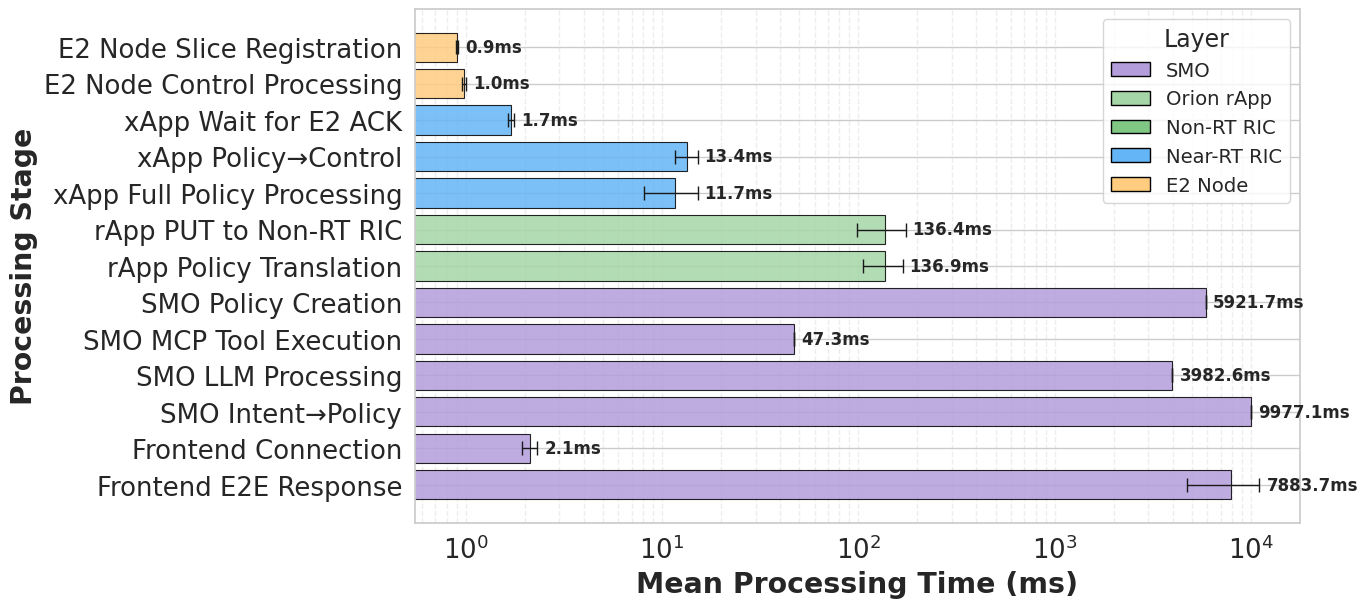


✓ Chart saved to processing_time_by_stage.png and processing_time_by_stage.pdf


In [29]:
# Bar Graph: Mean Processing Time by Stage
if len(df_processing) > 0:
    # Calculate mean and std processing time per label (stage)
    stage_stats = df_processing.groupby(["layer", "label"])["processing_time_ms"].agg(["mean", "std"]).fillna(0)
    
    # Define flow order for stages (top to bottom in chart = end to start of flow)
    # Flow: Frontend → SMO → rApp → Non-RT RIC → Near-RT RIC → E2 Node
    flow_order = [
        # E2 Node (end of flow - top of chart)
        "E2 Node Slice Registration",
        "E2 Node Control Processing",
        # Near-RT RIC
        "E2Term Control Round-trip",
        "xApp Wait for E2 ACK",
        "xApp Policy→Control",
        "xApp Policy Parsing",
        "xApp Full Policy Processing",
        "A1 Mediator Processing",
        # Non-RT RIC
        # rApp
        "rApp PUT to Non-RT RIC",
        "rApp Policy Translation",
        # SMO
        "MCP Server Session→Request",
        "SMO Policy Creation",
        "SMO MCP Tool Execution",
        "SMO LLM Processing",
        "SMO Intent→Policy",
        # Frontend (start of flow - bottom of chart)
        "Frontend Connection",
        "Frontend E2E Response",
    ]
    
    # Sort by flow order using a helper column
    stage_stats = stage_stats.reset_index()
    stage_stats['flow_order'] = stage_stats['label'].apply(
        lambda x: flow_order.index(x) if x in flow_order else 999
    )
    stage_stats = stage_stats.sort_values('flow_order', ascending=False)
    
    # Define colors based on architecture (matching namespace_resources.ipynb style)
    layer_colors = {
        "Frontend": "#B39DDB",   # Purple (SMO style)
        "SMO": "#B39DDB",        # Purple
        "rApp": "#A5D6A7",       # Green
        "Non-RT RIC": "#81C784", # Green (darker)
        "Near-RT RIC": "#64B5F6", # Blue
        "E2 Node": "#FFCC80",    # Orange
    }
    
    # Create the plot data
    labels = stage_stats["label"].values
    means = stage_stats["mean"].values
    stds = stage_stats["std"].values
    colors = [layer_colors.get(layer, "#888888") for layer in stage_stats["layer"].values]
    
    # Create bar chart with consistent style
    fig, ax = plt.subplots(figsize=(14, max(6, len(labels) * 0.5)))
    
    bars = ax.barh(labels, means, xerr=stds, capsize=5,
                   color=colors, edgecolor='black', linewidth=0.8, alpha=0.85,
                   error_kw=dict(lw=1, capsize=5, capthick=1))
    
    # Add value labels (mean only)
    for bar, mean, std in zip(bars, means, stds):
        if mean > 0:
            width_right = mean + std if std > 0 else mean
            ax.annotate(f'{mean:.1f}ms',
                       xy=(width_right, bar.get_y() + bar.get_height() / 2),
                       xytext=(5, 0), textcoords="offset points",
                       ha='left', va='center', fontsize=12, fontweight='bold')
    
    ax.set_xlabel("Mean Processing Time (ms)", fontweight='bold')
    ax.set_ylabel("Processing Stage", fontweight='bold')
    ax.set_xscale('log')
    ax.grid(axis='x', linestyle='--', alpha=0.35, which='both')
    
    # Add legend for layers
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#B39DDB', edgecolor='black', label='SMO'),
        Patch(facecolor='#A5D6A7', edgecolor='black', label='Orion rApp'),
        Patch(facecolor='#81C784', edgecolor='black', label='Non-RT RIC'),
        Patch(facecolor='#64B5F6', edgecolor='black', label='Near-RT RIC'),
        Patch(facecolor='#FFCC80', edgecolor='black', label='E2 Node'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', title="Layer", fontsize='x-small', title_fontsize='small')
    
    plt.tight_layout()
    plt.savefig("processing_time_by_stage.png", dpi=300, bbox_inches="tight")
    plt.savefig("processing_time_by_stage.pdf", bbox_inches="tight")
    plt.show()
    print("\n✓ Chart saved to processing_time_by_stage.png and processing_time_by_stage.pdf")
else:
    print("No data available for visualization.")

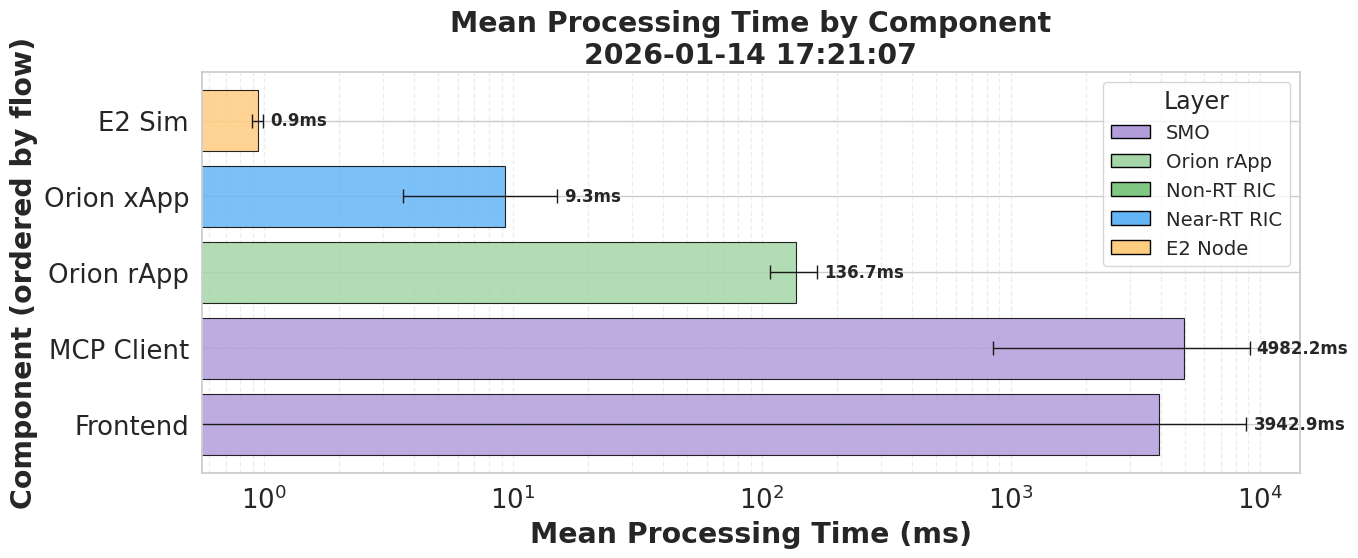


✓ Chart saved to processing_time_by_component.png and processing_time_by_component.pdf


In [30]:
# Bar Graph: Mean Processing Time by Component
if len(df_processing) > 0:
    # Calculate mean and std processing time per component
    component_stats = df_processing.groupby(["layer", "component"])["processing_time_ms"].agg(["mean", "std"]).fillna(0)
    
    # Define flow order for components (top to bottom in chart = end to start of flow)
    # Flow: Frontend → SMO → rApp → Non-RT RIC → Near-RT RIC → E2 Node
    component_flow_order = [
        "e2sim",          # E2 Node (end of flow)
        "e2term",         # Near-RT RIC
        "orion-xapp",     # Near-RT RIC
        "a1mediator",     # Near-RT RIC
        "e2mgr",          # Near-RT RIC
        "a1controller",   # Non-RT RIC
        "policymanagement", # Non-RT RIC
        "rapp",           # rApp
        "mcp-server",     # SMO
        "mcp-client",     # SMO
        "frontend",       # Frontend (start of flow - bottom of chart)
    ]
    
    # Sort by flow order
    component_stats['flow_order'] = [
        component_flow_order.index(idx[1]) if idx[1] in component_flow_order else 999 
        for idx in component_stats.index
    ]
    component_stats = component_stats.sort_values('flow_order', ascending=False).drop(columns=['flow_order'])
    
    # Define colors based on architecture (matching namespace_resources.ipynb style)
    layer_colors = {
        "Frontend": "#B39DDB",   # Purple
        "SMO": "#B39DDB",        # Purple
        "rApp": "#A5D6A7",       # Green
        "Non-RT RIC": "#81C784", # Green (darker)
        "Near-RT RIC": "#64B5F6", # Blue
        "E2 Node": "#FFCC80",    # Orange
    }
    
    # Define display labels for components (matching namespace_resources.ipynb naming)
    name_mapping = {
        "mcp-client": "MCP Client",
        "mcp-server": "MCP Server",
        "rapp": "Orion rApp",
        "policymanagement": "Policy Mgmt",
        "a1controller": "A1 Controller",
        "a1mediator": "A1 Mediator",
        "e2term": "E2 Term",
        "e2mgr": "E2 Mgr",
        "orion-xapp": "Orion xApp",
        "e2sim": "E2 Sim",
        "frontend": "Frontend",
    }
    
    # Create the plot data
    labels = [name_mapping.get(idx[1], idx[1]) for idx in component_stats.index]
    means = component_stats["mean"].values
    stds = component_stats["std"].values
    colors = [layer_colors.get(idx[0], "#888888") for idx in component_stats.index]
    
    # Create bar chart with consistent style
    fig, ax = plt.subplots(figsize=(14, max(6, len(labels) * 0.6)))
    
    bars = ax.barh(labels, means, xerr=stds, capsize=5,
                   color=colors, edgecolor='black', linewidth=0.8, alpha=0.85,
                   error_kw=dict(lw=1, capsize=5, capthick=1))
    
    # Add value labels (mean only)
    for bar, mean, std in zip(bars, means, stds):
        if mean > 0:
            width_right = mean + std if std > 0 else mean
            ax.annotate(f'{mean:.1f}ms',
                       xy=(width_right, bar.get_y() + bar.get_height() / 2),
                       xytext=(5, 0), textcoords="offset points",
                       ha='left', va='center', fontsize=12, fontweight='bold')
    
    ax.set_xlabel("Mean Processing Time (ms)", fontweight='bold')
    ax.set_ylabel("Component (ordered by flow)", fontweight='bold')
    ax.set_title(f"Mean Processing Time by Component\n{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", 
                 fontweight="bold")
    ax.set_xscale('log')
    ax.grid(axis='x', linestyle='--', alpha=0.35, which='both')
    
    # Add legend for layers
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#B39DDB', edgecolor='black', label='SMO'),
        Patch(facecolor='#A5D6A7', edgecolor='black', label='Orion rApp'),
        Patch(facecolor='#81C784', edgecolor='black', label='Non-RT RIC'),
        Patch(facecolor='#64B5F6', edgecolor='black', label='Near-RT RIC'),
        Patch(facecolor='#FFCC80', edgecolor='black', label='E2 Node'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', title="Layer", fontsize='x-small', title_fontsize='small')
    
    plt.tight_layout()
    plt.savefig("processing_time_by_component.png", dpi=300, bbox_inches="tight")
    plt.savefig("processing_time_by_component.pdf", bbox_inches="tight")
    plt.show()
    print("\n✓ Chart saved to processing_time_by_component.png and processing_time_by_component.pdf")
else:
    print("No data available for visualization.")

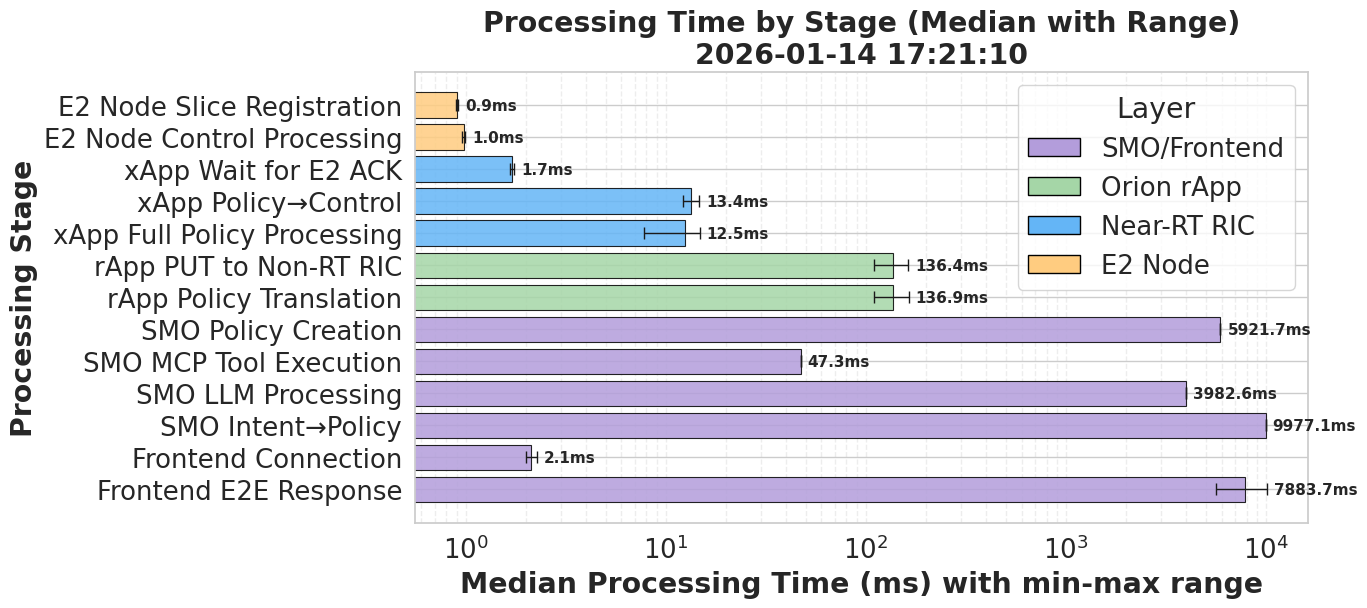


✓ Chart saved to processing_time_by_stage_median.png and processing_time_by_stage_median.pdf

Note: Error bars show min-max range. Median is more robust than mean for small samples.


In [31]:
# Chart: Median Processing Time by Stage (more robust to outliers)
if len(df_processing) > 0:
    # Use median instead of mean for more robust statistics
    stage_stats = df_processing.groupby(["layer", "label"])["processing_time_ms"].agg(["median", "min", "max", "count"]).reset_index()
    
    # Calculate error as (max-min)/2 for small samples, or use IQR for larger samples
    def calc_error(group):
        if len(group) >= 4:
            return (group.quantile(0.75) - group.quantile(0.25)) / 2
        else:
            return (group.max() - group.min()) / 2
    
    stage_stats["error"] = df_processing.groupby(["layer", "label"])["processing_time_ms"].apply(calc_error).values
    
    # Sort by flow order
    flow_order = [
        "E2 Node Slice Registration", "E2 Node Control Processing",
        "xApp Wait for E2 ACK", "xApp Policy→Control", "xApp Policy Parsing", "xApp Full Policy Processing",
        "A1 Mediator Processing",
        "rApp PUT to Non-RT RIC", "rApp Policy Translation",
        "MCP Server Session→Request", "SMO Policy Creation", "SMO MCP Tool Execution", 
        "SMO LLM Processing", "SMO Intent→Policy",
        "Frontend Connection", "Frontend E2E Response",
    ]
    stage_stats['flow_order'] = stage_stats['label'].apply(lambda x: flow_order.index(x) if x in flow_order else 999)
    stage_stats = stage_stats.sort_values('flow_order', ascending=False)
    
    # Colors
    layer_colors = {
        "Frontend": "#B39DDB", "SMO": "#B39DDB", "rApp": "#A5D6A7",
        "Non-RT RIC": "#81C784", "Near-RT RIC": "#64B5F6", "E2 Node": "#FFCC80",
    }
    
    fig, ax = plt.subplots(figsize=(14, max(6, len(stage_stats) * 0.5)))
    
    colors = [layer_colors.get(row["layer"], "#888888") for _, row in stage_stats.iterrows()]
    
    # Use asymmetric error bars: show range from min to max
    errors_low = stage_stats["median"] - stage_stats["min"]
    errors_high = stage_stats["max"] - stage_stats["median"]
    
    bars = ax.barh(stage_stats["label"], stage_stats["median"],
                   xerr=[errors_low, errors_high], capsize=4,
                   color=colors, edgecolor='black', linewidth=0.8, alpha=0.85,
                   error_kw=dict(lw=1, capsize=4, capthick=1))
    
    # Add value labels
    for i, (_, row) in enumerate(stage_stats.iterrows()):
        median_val = row["median"]
        max_val = row["max"]
        ax.annotate(f'{median_val:.1f}ms',
                   xy=(max_val, i), xytext=(5, 0), textcoords="offset points",
                   ha='left', va='center', fontsize=11, fontweight='bold')
    
    ax.set_xlabel("Median Processing Time (ms) with min-max range", fontweight='bold')
    ax.set_ylabel("Processing Stage", fontweight='bold')
    ax.set_title(f"Processing Time by Stage (Median with Range)\n{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", 
                 fontweight="bold")
    ax.set_xscale('log')
    ax.grid(axis='x', linestyle='--', alpha=0.35, which='both')
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#B39DDB', edgecolor='black', label='SMO/Frontend'),
        Patch(facecolor='#A5D6A7', edgecolor='black', label='Orion rApp'),
        Patch(facecolor='#64B5F6', edgecolor='black', label='Near-RT RIC'),
        Patch(facecolor='#FFCC80', edgecolor='black', label='E2 Node'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', title="Layer")
    
    plt.tight_layout()
    plt.savefig("processing_time_by_stage_median.png", dpi=300, bbox_inches="tight")
    plt.savefig("processing_time_by_stage_median.pdf", bbox_inches="tight")
    plt.show()
    print("\n✓ Chart saved to processing_time_by_stage_median.png and processing_time_by_stage_median.pdf")
    print("\nNote: Error bars show min-max range. Median is more robust than mean for small samples.")